<a href="https://colab.research.google.com/github/banerjee109/Infotact-Project-2/blob/main/cohort_retention_cltv_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(7)
random.seed(7)

# ============================================================
# CloudSync SaaS — Subscription Billing Dataset
# Simulates 18 months of subscription history for a B2B SaaS product
# ============================================================

NUM_CUSTOMERS = 2500
START_DATE = datetime(2023, 1, 1)
NUM_MONTHS = 18

PLAN_TIERS = {
    'Starter':    {'mrr': 15,  'churn_risk': 0.14},   # cheap plan -> churns faster
    'Growth':     {'mrr': 49,  'churn_risk': 0.08},
    'Scale':      {'mrr': 129, 'churn_risk': 0.05},
    'Enterprise': {'mrr': 399, 'churn_risk': 0.02},   # sticky, high-touch customers
}

CHANNELS = ['Organic_Search', 'Paid_Ads', 'Referral', 'Outbound_Sales', 'Partner_Integration']
INDUSTRIES = ['E-commerce', 'FinTech', 'Healthcare', 'EdTech', 'Manufacturing', 'Agency']
CANCEL_REASONS = ['Too_Expensive', 'Missing_Features', 'Switched_Competitor', 'Poor_Support', 'No_Longer_Needed', None]

print("Simulating CloudSync subscription lifecycle...")

rows = []
customer_num = 1000

for _ in range(NUM_CUSTOMERS):
    customer_id = f'CS_{customer_num}'
    customer_num += 1

    # Weighted signup month -> more customers joined earlier (natural for cohort spread)
    signup_offset = np.random.choice(
        range(NUM_MONTHS - 2),
        p=np.array([1/(m+1)**0.5 for m in range(NUM_MONTHS - 2)]) /
          sum(1/(m+1)**0.5 for m in range(NUM_MONTHS - 2))
    )
    signup_date = START_DATE + timedelta(days=int(signup_offset * 30 + random.randint(0, 27)))

    plan = random.choices(list(PLAN_TIERS.keys()), weights=[45, 30, 18, 7])[0]
    channel = random.choices(CHANNELS, weights=[30, 25, 20, 15, 10])[0]
    industry = random.choice(INDUSTRIES)
    company_size = random.choice(['1-10', '11-50', '51-200', '201-500', '500+'])

    base_churn = PLAN_TIERS[plan]['churn_risk']
    mrr = PLAN_TIERS[plan]['mrr']

    is_active = True
    current_month = 0
    cancel_reason = None
    plan_history = plan

    while is_active and (signup_offset + current_month) < NUM_MONTHS:
        billing_date = signup_date + timedelta(days=30 * current_month)

        # Occasional upgrade after month 3 (happy customers expanding)
        if current_month == 3 and plan != 'Enterprise' and random.random() < 0.12:
            tiers = list(PLAN_TIERS.keys())
            idx = tiers.index(plan_history)
            plan_history = tiers[min(idx + 1, len(tiers) - 1)]
            mrr = PLAN_TIERS[plan_history]['mrr']

        rows.append({
            'customer_id': customer_id,
            'billing_date': billing_date.strftime('%Y-%m-%d'),
            'signup_date': signup_date.strftime('%Y-%m-%d'),
            'plan_tier': plan_history,
            'mrr_usd': mrr,
            'acquisition_channel': channel,
            'industry': industry,
            'company_size': company_size,
            'event_type': 'renewal' if current_month > 0 else 'new_signup',
            'cancellation_reason': None
        })

        # Determine churn — risk grows slightly over time (fatigue), but drops after month 6 (loyal core)
        month_factor = 1.3 if current_month < 3 else (1.0 if current_month < 6 else 0.6)
        churn_prob = base_churn * month_factor

        if random.random() < churn_prob:
            is_active = False
            cancel_reason = random.choices(
                CANCEL_REASONS,
                weights=[30, 25, 20, 15, 10, 0]
            )[0]
            rows.append({
                'customer_id': customer_id,
                'billing_date': (billing_date + timedelta(days=30)).strftime('%Y-%m-%d'),
                'signup_date': signup_date.strftime('%Y-%m-%d'),
                'plan_tier': plan_history,
                'mrr_usd': 0,
                'acquisition_channel': channel,
                'industry': industry,
                'company_size': company_size,
                'event_type': 'cancellation',
                'cancellation_reason': cancel_reason
            })

        current_month += 1

df = pd.DataFrame(rows)
df = df.sample(frac=1, random_state=7).reset_index(drop=True)  # shuffle like a real export

df.to_csv('cloudsync_subscriptions.csv', index=False)
print(f"✅ cloudsync_subscriptions.csv created — {len(df)} rows, {NUM_CUSTOMERS} customers")
print(df.head(10))
df = pd.read_csv('cloudsync_subscriptions.csv')
df.info()
df['event_type'].value_counts()
from google.colab import files
##files.download('cloudsync_subscriptions.csv')

Simulating CloudSync subscription lifecycle...
✅ cloudsync_subscriptions.csv created — 19422 rows, 2500 customers
  customer_id billing_date signup_date   plan_tier  mrr_usd  \
0     CS_2363   2023-03-24  2023-02-22       Scale      129   
1     CS_1564   2023-03-02  2023-01-01     Starter       15   
2     CS_2215   2024-02-28  2023-10-01     Starter       15   
3     CS_2261   2024-03-29  2023-01-04     Starter       15   
4     CS_2525   2023-12-17  2023-12-17     Starter       15   
5     CS_3382   2023-05-13  2023-05-13     Starter       15   
6     CS_2113   2023-02-25  2023-01-26  Enterprise      399   
7     CS_2879   2024-03-04  2024-02-03     Starter        0   
8     CS_2768   2024-05-02  2023-09-05      Growth       49   
9     CS_3216   2024-02-14  2023-08-18       Scale      129   

   acquisition_channel    industry company_size    event_type  \
0             Paid_Ads     FinTech        11-50       renewal   
1             Referral     FinTech         500+       renewal 

In [2]:
import pandas as pd
import numpy as np
import datetime as dt
pd.set_option('display.max_rows' ,None)
pd.set_option('display.max_columns' ,None)
df=pd.read_csv("cloudsync_subscriptions.csv")
df.info()
df.describe()
df.head()
df.columns
df.columns.nunique()
df.isna().sum()
df["customer_id"].nunique()
len(df["customer_id"])
df["company_size"].idxmax()
df["billing_date"].head()
df["billing_date"]=pd.to_datetime(df["billing_date"])
df["billing_date"].head()
df["billing_day"]=df["billing_date"].dt.day
df["billing_month"]=df["billing_date"].dt.month
df["billing_year"]=df["billing_date"].dt.year
df["billing_day_name"]=df["billing_date"].dt.day_name()
df["billing_day_name"].unique()
df["billing_year"].unique()
df["billing_month"].nunique()
missing_percent = (df.isna().sum() / len(df))*100
missing_percent
df.head(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19422 entries, 0 to 19421
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          19422 non-null  object
 1   billing_date         19422 non-null  object
 2   signup_date          19422 non-null  object
 3   plan_tier            19422 non-null  object
 4   mrr_usd              19422 non-null  int64 
 5   acquisition_channel  19422 non-null  object
 6   industry             19422 non-null  object
 7   company_size         19422 non-null  object
 8   event_type           19422 non-null  object
 9   cancellation_reason  1546 non-null   object
dtypes: int64(1), object(9)
memory usage: 1.5+ MB


,customer_id,billing_date,signup_date,plan_tier,mrr_usd,acquisition_channel,industry,company_size,event_type,cancellation_reason,billing_day,billing_month,billing_year,billing_day_name
0,CS_2363,2023-03-24,2023-02-22,Scale,129,Paid_Ads,FinTech,11-50,renewal,NaN,24,3,2023,Friday


In [ ]:
df.head(5)
df.groupby("acquisition_channel")["mrr_usd"].sum()
df.groupby("billing_month")["mrr_usd"].sum()
df.tail(2)
df["cancellation_reason"].dropna()
df.head()
df.sort_values(["customer_id","billing_date"])
first_acquisition= df.groupby("customer_id")["billing_date"].first().reset_index()
last_acquisition= df.groupby("customer_id")["billing_date"].last().reset_index()
df.head()
df.groupby("industry")["mrr_usd"].sum()
df.groupby("billing_day_name")["mrr_usd"].mean()
df.groupby(["industry","billing_day_name"])["mrr_usd"].sum()
##New customers every month
df[(df["event_type"]=="new_signup")]["customer_id"].nunique()
##df["signup_month"]=pd.to_datetime(df["signup_date"]).dt.to_period("M")
df["signup_month"] = pd.to_datetime(df["signup_date"]).dt.to_period("M")
df["signup_month"].nunique()
monthly_new_signups= df[(df["event_type"]=="new_signup")].groupby("signup_month")["customer_id"].nunique()
monthly_new_signups
df["cancellation_reason"].unique()
df.groupby("plan_tier")["mrr_usd"].sum().sort_values(ascending=False).reset_index()
df.groupby("industry")["mrr_usd"].sum().sort_values(ascending=False).reset_index()
df.groupby("company_size")["mrr_usd"].sum().sort_values(ascending=False).reset_index()
df.groupby("event_type")["customer_id"].nunique()
df.tail()
df["acquisition_channel"].nunique()
df.groupby("acquisition_channel")["mrr_usd"].agg(["sum","mean"]).sort_values(by="sum",ascending=False).reset_index()


,acquisition_channel,sum,mean
0,Organic_Search,587933,99.062005
1,Paid_Ads,425060,86.658512
2,Referral,386202,94.425917
3,Outbound_Sales,254860,95.026100
4,Partner_Integration,163473,90.316575


In [3]:
df.head()
df.columns
df.shape


(19422, 14)

In [4]:
total_customers = df["customer_id"].nunique()
active_customers = df[df["event_type"]!="cancellation"]["customer_id"].nunique()
total_mrr = df["mrr_usd"].sum()
average_mrr = df["mrr_usd"].mean()
new_customers = df[df["event_type"]=="new_signup"]["customer_id"].nunique()


In [22]:
churned_customers = df["cancellation_reason"].notna().sum()
churned_customers
churn_rate = (churned_customers / total_customers) * 100
churn_rate
retention_rate = 100 - churn_rate
retention_rate

,customer_id,billing_date,signup_date,plan_tier,mrr_usd,acquisition_channel,industry,company_size,event_type,cancellation_reason,billing_day,billing_month,billing_year,billing_day_name,cohort_month,cohort_index
0,CS_2363,2023-03-24,2023-02-22,Scale,129,Paid_Ads,FinTech,11-50,renewal,NaN,24,2023-03,2023,Friday,2023-02,1
1,CS_1564,2023-03-02,2023-01-01,Starter,15,Referral,FinTech,500+,renewal,NaN,2,2023-03,2023,Thursday,2023-01,2
2,CS_2215,2024-02-28,2023-10-01,Starter,15,Organic_Search,Healthcare,11-50,renewal,NaN,28,2024-02,2024,Wednesday,2023-10,4
3,CS_2261,2024-03-29,2023-01-04,Starter,15,Partner_Integration,E-commerce,51-200,renewal,NaN,29,2024-03,2024,Friday,2023-01,14
4,CS_2525,2023-12-17,2023-12-17,Starter,15,Paid_Ads,Healthcare,500+,new_signup,NaN,17,2023-12,2023,Sunday,2023-12,0


In [23]:
revenue_by_channel = df.groupby("acquisition_channel")["mrr_usd"].sum().sort_values(ascending=False).reset_index()
avg_revenue_channel = df.groupby("acquisition_channel")["mrr_usd"].mean().sort_values(ascending=False).reset_index()
customers_by_channel =df.groupby("acquisition_channel")["customer_id"].nunique().reset_index(name="customers")
monthly_signups = df[df["event_type"]=="new_signup"].groupby("signup_date")["customer_id"].nunique().reset_index(name="new_customers")
revenue_by_plan = df.groupby("plan_tier")["mrr_usd"].sum().sort_values(ascending=False).reset_index()
customers_by_plan = df.groupby("plan_tier")["customer_id"].nunique().reset_index(name="customers")
avg_plan =df.groupby("plan_tier")["mrr_usd"].mean().sort_values(ascending=False).reset_index()
company_revenue = df.groupby("company_size")["mrr_usd"].sum().sort_values(ascending=False).reset_index()
industry_revenue = df.groupby("industry")["mrr_usd"].sum().sort_values(ascending=False).reset_index()
industry_avg = df.groupby("industry")["mrr_usd"].mean().sort_values(ascending=False).reset_index()


In [24]:
cancel_reason = df.groupby("cancellation_reason")["customer_id"].nunique().sort_values(ascending=False).reset_index(name="customers")
churn_plan = df[df["cancellation_reason"].notna()].groupby("plan_tier")["customer_id"].nunique().reset_index(name="churned_customers")
churn_channel = df[df["cancellation_reason"].notna()].groupby("acquisition_channel")["customer_id"].nunique().reset_index(name="churned_customers")
revenue_per_customer = total_mrr / total_customers
revenue_per_customer
customer_lifetime = df.groupby("customer_id")["billing_month"].nunique().mean()
cltv = revenue_per_customer * customer_lifetime
cltv

np.float64(5552.9115456)

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure datetime
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["billing_date"] = pd.to_datetime(df["billing_date"])

# Cohort Month (Month of Signup)
df["cohort_month"] = df["signup_date"].dt.to_period("M")

# Billing Month
df["billing_month"] = df["billing_date"].dt.to_period("M")

# Cohort Index
df["cohort_index"] = ((df["billing_month"].dt.year - df["cohort_month"].dt.year) * 12+ (df["billing_month"].dt.month - df["cohort_month"].dt.month))

# Cohort Table (Retained Users)
cohort_data = (df.groupby(["cohort_month", "cohort_index"])["customer_id"].nunique().reset_index())
cohort_matrix = cohort_data.pivot(index="cohort_month",columns="cohort_index",values="customer_id")
cohort_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
cohort_month,,,,,,,,,,,,,,,,,,,
2023-01,418.0,396.0,373.0,331.0,293.0,272.0,236.0,217.0,207.0,196.0,184.0,176.0,165.0,146.0,143.0,138.0,136.0,98.0,3.0
2023-02,255.0,255.0,228.0,192.0,170.0,151.0,135.0,124.0,115.0,113.0,107.0,101.0,90.0,92.0,87.0,85.0,68.0,1.0,NaN
2023-03,228.0,228.0,205.0,174.0,154.0,136.0,128.0,114.0,105.0,100.0,94.0,87.0,84.0,77.0,74.0,58.0,2.0,NaN,NaN
2023-04,191.0,191.0,164.0,151.0,131.0,115.0,101.0,92.0,89.0,85.0,77.0,75.0,72.0,68.0,48.0,2.0,NaN,NaN,NaN
2023-05,172.0,171.0,158.0,142.0,129.0,109.0,105.0,96.0,92.0,86.0,83.0,75.0,69.0,48.0,3.0,NaN,NaN,NaN,NaN
2023-06,152.0,152.0,134.0,113.0,99.0,90.0,81.0,72.0,64.0,64.0,63.0,60.0,50.0,3.0,NaN,NaN,NaN,NaN,NaN
2023-07,137.0,137.0,115.0,103.0,94.0,91.0,81.0,70.0,63.0,63.0,58.0,38.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,129.0,127.0,111.0,98.0,91.0,84.0,79.0,74.0,69.0,66.0,49.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,122.0,122.0,106.0,90.0,78.0,70.0,66.0,63.0,62.0,48.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
retention_matrix = cohort_matrix.divide(cohort_matrix[0], axis=0) * 100
retention_matrix.round(2)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
cohort_month,,,,,,,,,,,,,,,,,,,
2023-01,100.0,94.74,89.23,79.19,70.10,65.07,56.46,51.91,49.52,46.89,44.02,42.11,39.47,34.93,34.21,33.01,32.54,23.44,0.72
2023-02,100.0,100.00,89.41,75.29,66.67,59.22,52.94,48.63,45.10,44.31,41.96,39.61,35.29,36.08,34.12,33.33,26.67,0.39,NaN
2023-03,100.0,100.00,89.91,76.32,67.54,59.65,56.14,50.00,46.05,43.86,41.23,38.16,36.84,33.77,32.46,25.44,0.88,NaN,NaN
2023-04,100.0,100.00,85.86,79.06,68.59,60.21,52.88,48.17,46.60,44.50,40.31,39.27,37.70,35.60,25.13,1.05,NaN,NaN,NaN
2023-05,100.0,99.42,91.86,82.56,75.00,63.37,61.05,55.81,53.49,50.00,48.26,43.60,40.12,27.91,1.74,NaN,NaN,NaN,NaN
2023-06,100.0,100.00,88.16,74.34,65.13,59.21,53.29,47.37,42.11,42.11,41.45,39.47,32.89,1.97,NaN,NaN,NaN,NaN,NaN
2023-07,100.0,100.00,83.94,75.18,68.61,66.42,59.12,51.09,45.99,45.99,42.34,27.74,1.46,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,100.0,98.45,86.05,75.97,70.54,65.12,61.24,57.36,53.49,51.16,37.98,0.78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,100.0,100.00,86.89,73.77,63.93,57.38,54.10,51.64,50.82,39.34,2.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


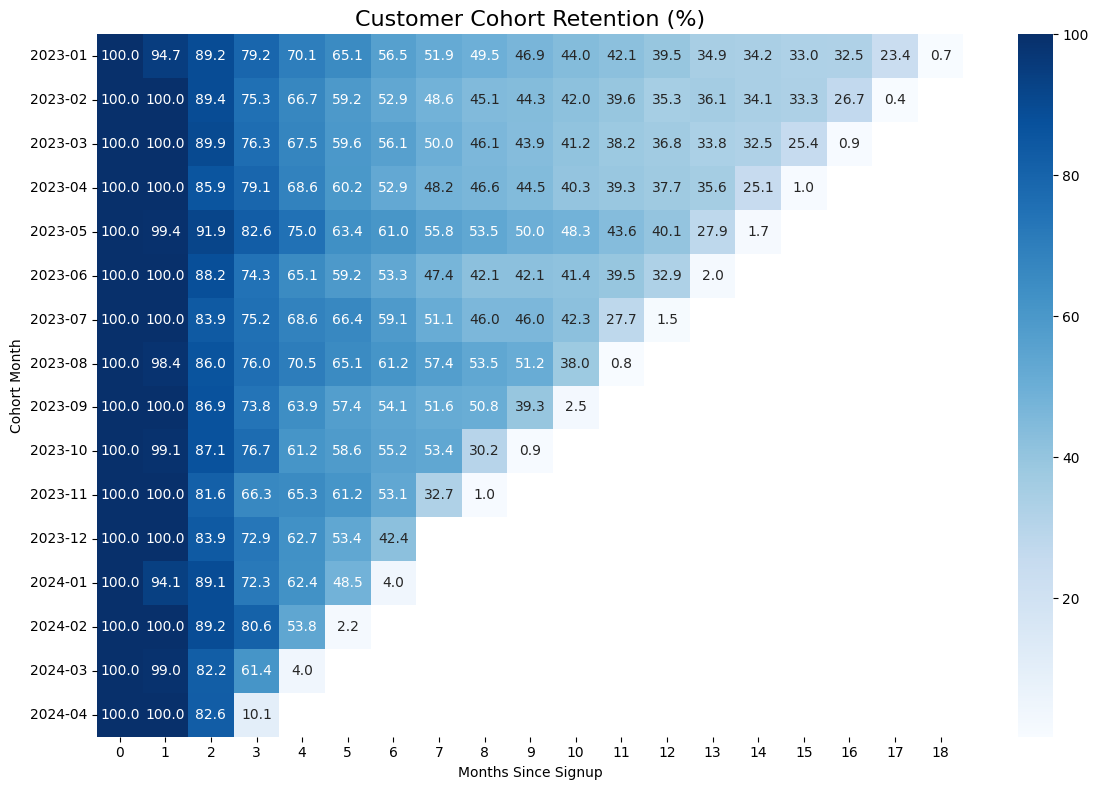

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(retention_matrix,annot=True,fmt=".1f",cmap="Blues")
plt.title("Customer Cohort Retention (%)", fontsize=16)
plt.xlabel("Months Since Signup")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

In [10]:
df.to_csv("saas_cohort_retention_cltv.csv",index=False)
from google.colab import files
files.download("saas_cohort_retention_cltv.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>